<a href="https://colab.research.google.com/github/Rohanrathod7/my-ds-labs/blob/main/28_Sampling_in_Python/04_Bootstrap_Distributions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import datetime as dt


In [6]:

import pandas as pd

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/28_Sampling_in_Python/dataset/spotify_2000_2020.feather"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
spotify_sample = pd.read_feather(url)
display(spotify_sample.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/26_Introduction_to_Regression_with_statsmodels_in_Python/dataset/churn.csv"
# Read the CSV file
churn = pd.read_csv(url)
display(churn.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/26_Introduction_to_Regression_with_statsmodels_in_Python/dataset/ad_conversion.csv"
# Read the CSV file
ad_conversion = pd.read_csv(url)
display(ad_conversion.head())

,acousticness,artists,danceability,duration_ms,duration_minutes,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,valence,year
0,0.97200,['David Bauer'],0.567,313293.0,5.221550,0.227,0.0,0w0D8H1ubRerCXHWYJkinO,0.601000,10.0,0.110,-13.441,1.0,Shout to the Lord,47.0,2000,0.0290,136.123,0.0396,2000.0
1,0.32100,['Etta James'],0.821,360240.0,6.004000,0.418,0.0,4JVeqfE2tpi7Pv63LJZtPh,0.000372,9.0,0.222,-9.841,0.0,Miss You,51.0,2000-12-12,0.0407,117.382,0.8030,2000.0
2,0.00659,['Quasimoto'],0.706,202507.0,3.375117,0.602,1.0,5pxtdhLAi0RTh1gNqhGMNA,0.000138,11.0,0.400,-8.306,0.0,Real Eyes,44.0,2000-06-13,0.3420,89.692,0.4790,2000.0
3,0.00390,['Millencolin'],0.368,173360.0,2.889333,0.977,0.0,3jRsoe4Vkxa4BMYqGHX8L0,0.000000,11.0,0.350,-2.757,0.0,Penguins & Polarbears,52.0,2000-02-22,0.1270,165.889,0.5480,2000.0
4,0.12200,['Steve Chou'],0.501,344200.0,5.736667,0.511,0.0,4mronxcllhfyhBRqyZi8kU,0.000000,7.0,0.279,-9.836,0.0,黃昏,53.0,2000-12-25,0.0291,78.045,0.1130,2000.0


,has_churned,time_since_first_purchase,time_since_last_purchase
0,0,-1.089221,-0.721322
1,0,1.182983,3.634435
2,0,-0.846156,-0.427582
3,0,0.086942,-0.535672
4,0,-1.166642,-0.672640


,spent_usd,n_impressions,n_clicks
0,1.43,7350,1
1,1.82,17861,2
2,1.25,4259,1
3,1.29,4133,1
4,4.77,15615,3


*The bootstrapping workflow is to generate a resample of the same size as the population, calculate a summary statistic, then repeat this to get a distribution of summary statistics.*

*The key to deciding whether to sample without or with replacement is whether or not your dataset is best thought of as being the whole population or not.*

**Generating a bootstrap distribution**  
The process for generating a bootstrap distribution is similar to the process for generating a sampling distribution; only the first step is different.

To make a sampling distribution, you start with the population and sample without replacement. To make a bootstrap distribution, you start with a sample and sample that with replacement. After that, the steps are the same: calculate the summary statistic that you are interested in on that sample/resample, then replicate the process many times. In each case, you can visualize the distribution with a histogram.

Here, spotify_sample is a subset of the spotify_population dataset. To make it easier to see how resampling works, a row index column called 'index' has been added, and only the artist name, song name, and danceability columns have been included.

spotify_sample is available; pandas, numpy, and matplotlib.pyplot are loaded with their usual aliases.

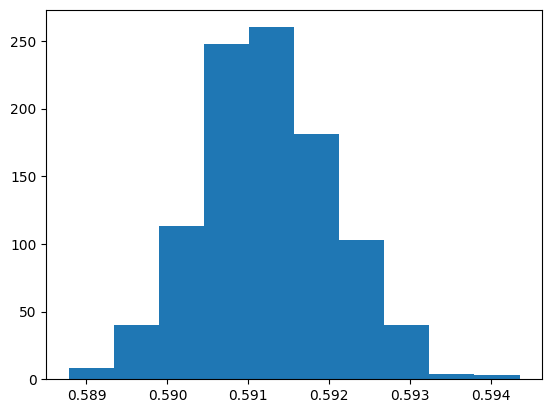

In [7]:
# Replicate this 1000 times
mean_danceability_1000 = []
for i in range(1000):
	mean_danceability_1000.append(
        np.mean(spotify_sample.sample(frac=1, replace=True)['danceability'])
	)

# Draw a histogram of the resample means
plt.hist(mean_danceability_1000)
plt.show()

# From the smaller sample of Spotify songs, we can estimate the mean danceability
# statistic in the population. Since we have a distribution of statistics, we can
# even quantify how accurate our estimate is.



**Sampling distribution vs. bootstrap distribution**   
The sampling distribution and bootstrap distribution are closely linked. In situations where you can repeatedly sample from a population (these occasions are rare), it's helpful to generate both the sampling distribution and the bootstrap distribution, one after the other, to see how they are related.

Here, the statistic you are interested in is the mean popularity score of the songs.

spotify_population (the whole dataset) and spotify_sample (500 randomly sampled rows from spotify_population) are available; pandas and numpy are loaded with their usual aliases.

In [8]:
mean_popularity_2000_boot = []

# Generate a bootstrap distribution of 2000 replicates
for i in range(2000):
    mean_popularity_2000_boot.append(
    spotify_sample.sample(n=500, replace=True)['popularity'].mean()
)

# Print the bootstrap distribution results
print(mean_popularity_2000_boot)

# The sampling distribution and bootstrap distribution are closely related, and so is the code to generate them.



[np.float64(54.006), np.float64(55.194), np.float64(54.86), np.float64(54.69), np.float64(53.904), np.float64(55.124), np.float64(54.496), np.float64(54.864), np.float64(55.55), np.float64(55.012), np.float64(54.164), np.float64(54.28), np.float64(54.648), np.float64(54.436), np.float64(54.996), np.float64(55.458), np.float64(54.06), np.float64(54.49), np.float64(54.79), np.float64(55.314), np.float64(55.454), np.float64(55.86), np.float64(55.158), np.float64(54.702), np.float64(54.692), np.float64(54.884), np.float64(55.194), np.float64(54.48), np.float64(54.148), np.float64(54.672), np.float64(54.558), np.float64(55.426), np.float64(55.672), np.float64(54.748), np.float64(55.092), np.float64(55.472), np.float64(55.356), np.float64(54.612), np.float64(54.54), np.float64(56.014), np.float64(54.354), np.float64(55.362), np.float64(54.668), np.float64(54.154), np.float64(55.676), np.float64(54.946), np.float64(54.334), np.float64(54.858), np.float64(54.466), np.float64(55.29), np.float64

**Compare sampling and bootstrap means**  
To make calculation easier, distributions similar to those calculated from the previous exercise have been included, this time using a sample size of 5000.

spotify_population, spotify_sample, sampling_distribution, and bootstrap_distribution are available; pandas and numpy are loaded with their usual aliases.

In [13]:
# Generate sampling distribution of 2000 replicates
sampling_distribution = []
for i in range(2000):
    sampling_distribution.append(
        spotify_2000_2020.sample(n=5000, replace=False)['popularity'].mean()
    )

# Generate bootstrap distribution of 2000 replicate
bootstrap_distribution = []
for i in range(2000):
    bootstrap_distribution.append(
        spotify_sample.sample(n=5000, replace=True)['popularity'].mean()
    )

In [14]:
# Calculate the population mean popularity
pop_mean = np.mean(spotify_2000_2020["popularity"])

# Calculate the original sample mean popularity
samp_mean = np.mean(spotify_sample["popularity"])

# Calculate the sampling dist'n estimate of mean popularity
samp_distn_mean = np.mean(sampling_distribution)

# Calculate the bootstrap dist'n estimate of mean popularity
boot_distn_mean = np.mean(bootstrap_distribution)

# Print the means
print([pop_mean, samp_mean, samp_distn_mean, boot_distn_mean])

# The sampling distribution mean can be used to estimate the population mean, but that is not the case with the bootstrap distribution.
# The sampling distribution mean is the best estimate of the true population mean; the bootstrap distribution mean is closest to the original sample mean.

[np.float64(54.837142308430955), np.float64(54.837142308430955), np.float64(54.8369749), np.float64(54.83999190000001)]


**Compare sampling and bootstrap standard deviations**  
In the same way that you looked at how the sampling distribution and bootstrap distribution could be used to estimate the population mean, you'll now take a look at how they can be used to estimate variation, or more specifically, the standard deviation, in the population.

Recall that the sample size is 5000.

spotify_population, spotify_sample, sampling_distribution, and bootstrap_distribution are available; pandas and numpy are loaded with their usual aliases.

In [16]:
# Calculate the population std dev popularity
pop_sd = spotify_2000_2020['popularity'].std(ddof=0)

# Calculate the original sample std dev popularity
samp_sd = spotify_sample['popularity'].std(ddof=1)

# Calculate the sampling dist'n estimate of std dev popularity
samp_distn_sd = np.std(sampling_distribution, ddof=1) * np.sqrt(5000)
# Calculate the bootstrap dist'n estimate of std dev popularity
boot_distn_sd = np.std(bootstrap_distribution, ddof=1) * np.sqrt(5000)

# Print the standard deviations
print([pop_sd, samp_sd, samp_distn_sd, boot_distn_sd])

# This is an important property of the bootstrap distribution. When you don't
# have all the values from the population or the ability to sample multiple times, you can use bootstrapping to get a good estimate of the population standard deviation.

[10.880065274257204, 10.88019587082396, np.float64(10.28033060502552), np.float64(11.02625293101874)]


*Confidence intervals account for uncertainty in our estimate of a population parameter by providing a range of possible values. We are confident that the true value lies somewhere in the interval specified by that range.*



**Calculating confidence intervals**  
You have learned about two methods for calculating confidence intervals: the quantile method and the standard error method. The standard error method involves using the inverse cumulative distribution function (inverse CDF) of the normal distribution to calculate confidence intervals. In this exercise, you'll perform these two methods on the Spotify data.

spotify_population, spotify_sample, and bootstrap_distribution are available; pandas and numpy are loaded with their usual aliases, and norm has been loaded from scipy.stats.

In [18]:
# Generate a 95% confidence interval using the quantile method
lower_quant = np.quantile(bootstrap_distribution, 0.025)
upper_quant = np.quantile(bootstrap_distribution, 0.975)

# Print quantile method confidence interval
print((lower_quant, upper_quant))

# Find the mean and std dev of the bootstrap distribution
point_estimate = np.mean(bootstrap_distribution)
standard_error = np.std(bootstrap_distribution, ddof=1)

from scipy.stats import norm
# Find the lower limit of the confidence interval
lower_se = norm.ppf(0.025, loc=point_estimate, scale=standard_error)

# Find the upper limit of the confidence interval
upper_se = norm.ppf(0.975, loc=point_estimate, scale=standard_error)

# Print standard error method confidence interval
print((lower_se, upper_se))

#  The standard error method for calculating the confidence interval assumes that
#  the bootstrap distribution is normal. This assumption should hold if the sample
#  size and number of replicates are sufficiently large.



(np.float64(54.532575), np.float64(55.14063))
(np.float64(54.534365377893096), np.float64(55.14561842210692))
